# Efficient Evaluation of Quantum Repeater Protocols

In [1]:
import logging
import time
import numpy as np
from matplotlib import pyplot as plt

from src.core.repeater_algorithm import RepeaterChainEvaluation
from src.core.bell.state import BellState
from src.core.werner.state import WernerState
from src.core.states import QuantumState
from src.optimization.gp_asymmetric import gaussian_optimization
from src.plotting.basic_plots import plot_algorithm
from src.types.repeater_types import SimParameters
from src.utils.utility_functions import werner_to_fid, bell_to_fid, get_mean_waiting_time, get_mean

logging.basicConfig(level=logging.INFO)

## Entanglement Generation and Swapping

First, we specify and evaluate a protocol performing entanglement swapping.
Here, we represent states as Werner states.

The first step of the protocol is the generation of short links through direct photon transmission over a fiber channel.
Once the two links are both ready, they are swapped.

This is specified in the tool as $(0,)$, since generation of all links is implicit (before any operations), and swapping is represented by $0$ in the tuple.

The output of a tool is a probability distribution describing how likely is to produce the end-to-end link at a given time $t$, given the probabilistic nature of the operations and losses in the channels.
Furthermore, we also get a description of how the Werner state's quality evolves over time, accounting for decoherence.

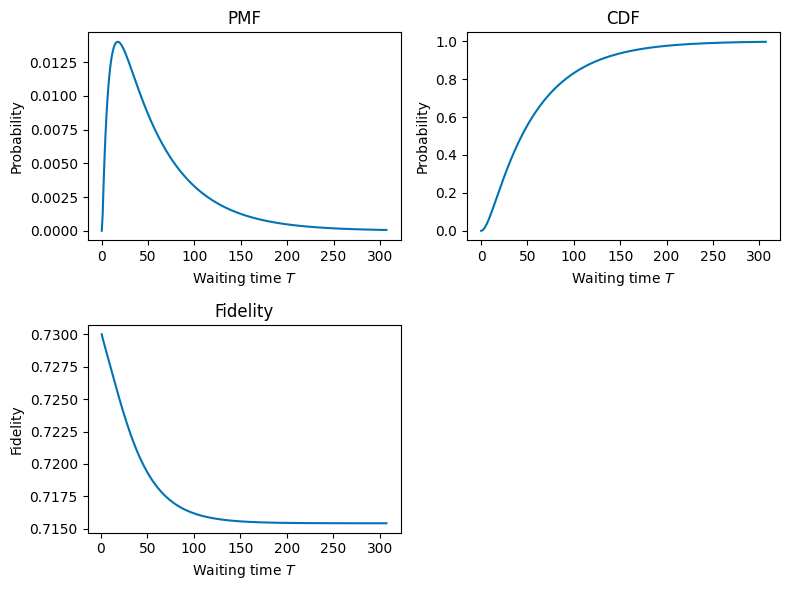

In [2]:
state_type : QuantumState = WernerState
machinery = RepeaterChainEvaluation(state_type=state_type)

parameters = {
    "protocol": (0,),
    "p_gen": 0.05,
    "p_swap": 0.5,
    "w0": 0.8,  # fidelity 0.85
    "t_coh": 1000, # depolarizing noise
    "t_trunc": 1000,
}

w_pmf, w_func = machinery.nested_protocol(parameters)
w_fid_func = [werner_to_fid(w) for w in w_func]
fig, axs = plot_algorithm(
    pmf=w_pmf,
    fid_func=w_fid_func,
)
plt.show()

Thus, with this tuple specification we test **nested** protocols, acting on $2^l+1$ nodes, e.g., 3 here ($l=1$),
and swapping the $l-1$ elementary links for $l$ nesting levels.

For example, the $(0,0)$ generates $4$ short links, swapped in the first level producing $2$ links, and finally swapped to produce the final link. 

## Bell diagonal state representation
Here, we can test a more fine-grained noise using a Bell diagonal state, with four parameters for the weights of the Bell states in the mixture.

Thus, we allow for other types of noise, e.g. dephasing, and evaluate their effect. 

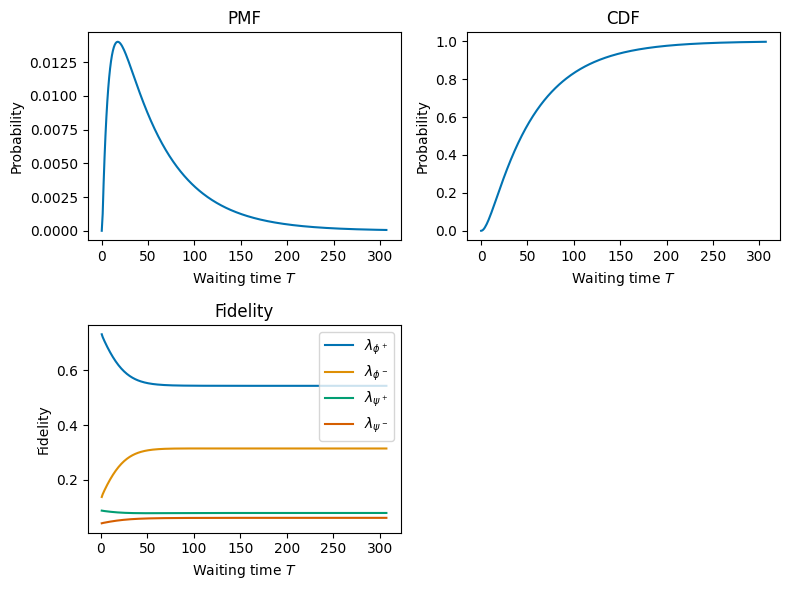

In [3]:
state_type : QuantumState = BellState
machinery = RepeaterChainEvaluation(state_type=state_type)

parameters = {
    "protocol": (0,),
    "p_gen": 0.05,
    "p_swap": 0.5,
    "lambdas": [0.85, 0.08, 0.05, 0.02],  # fidelity 0.85
    "depolarizing_rate": 0.001, # depolarizing noise
    "dephasing_rate": 0.05, # depolarizing noise
    "t_trunc": 1000,
}

b_pmf, l_func = machinery.nested_protocol(parameters)
fig, axs = plot_algorithm(
    pmf=b_pmf,
    fid_func=l_func,
    legend_fid=["$\\lambda_{\\phi^+}$", "$\\lambda_{\\phi^-}$", "$\\lambda_{\\psi^+}$", "$\\lambda_{\\psi^-}$"],
)
plt.show()

Notice that the probability distribution is the exact same as before.
This is because, ...

On the other hand, the state is here represented as Bell diagonal, and the weights for the four Bell states in the mixture evolve accounting for both dephasing and depolarizing noise.


We can compute the probability mass that is covered by this distribution, and calculate the average waiting time, comparing it with the analytical result.


In [4]:
coverage = np.sum(w_pmf)
print("Total probability mass:", coverage)

# We can also calculate the average waiting time and compare it with the analytical result.
numerical_result = get_mean_waiting_time(w_pmf) # numerical
p_gen = parameters["p_gen"]
p_swap = parameters["p_swap"]
print("Average waiting time, Werner states (numerical):", numerical_result)
numerical_result_bell = get_mean_waiting_time(b_pmf) # numerical
print("Average waiting time, Bell states (numerical):", numerical_result_bell)
analytical_result = (3-2*p_gen)/((2-p_gen)*p_gen*p_swap) # analytical
print("Average waiting time, Bell states (analytical):", analytical_result)

Total probability mass: 0.9999999953944039
Average waiting time, Werner states (numerical): 59.487179525672104
Average waiting time, Bell states (numerical): 59.487179525672104
Average waiting time, Bell states (analytical): 59.48717948717948


For this protocol, this should coincide, as it is now.
This is a good test of the validity of our evaluations.

(! Under the `test` module, an extensive testsuite evaluates the correctness of our tool
e.g., checking the two formalisms produce the same results if tested under the same condition)

Now, let's consider **fidelity**.
Here, we use `werner_to_fid` and `fid_to_werner` to transfer between the Werner parameter and the fidelity.
We use `bell_to_fid` to compute the fidelity of the Bell diagonal states.
We can compute the average fidelity of the final end-to-end links.

In [5]:
average_fidelity = get_mean(w_pmf, w_fid_func)
print("Average fidelity (Werner):", average_fidelity)
l_fid_func = [bell_to_fid(lambdas) for lambdas in l_func] # consider only lambda_phi+
average_fidelity_bell = get_mean(b_pmf, l_fid_func)
print("Average fidelity (Bell):", average_fidelity_bell)

Average fidelity (Werner): 0.7208250658519804
Average fidelity (Bell): 0.5803385085641589


Notice that the fidelity of the Bell state is lower, as expected due to the additional noise (dephasing) considered

## Entanglement Distillation
Entanglement distillation, a.k.a. purification, is used to consume two links of lower fidelity to produce one link of higher fidelity.
This is done probabilistically, and thus affects the waiting time.

In the nested protocol representation we encode distillation by placing a $1$ in the protocol tuple.
Here, we define and test a nested protocol with one level of distillation using Bell states.

We choose to either twirl the state after distillation or not by setting `twirling`.
By twirling after distillation, we get a Werner state (useful for comparison).

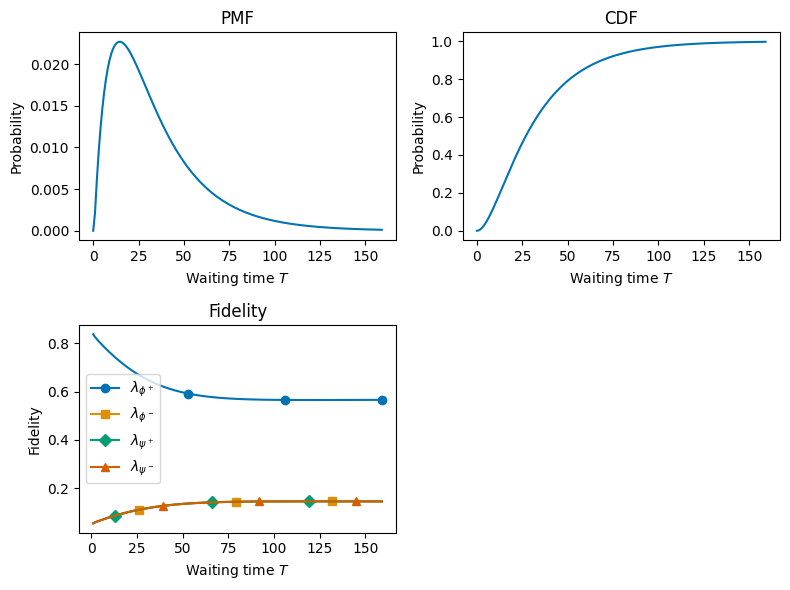

In [6]:
parameters["protocol"] = (1,)

state_type : QuantumState = BellState
machinery = RepeaterChainEvaluation(state_type=state_type, twirling=True)

dist_pmf, dist_sf = machinery.nested_protocol(parameters)
fig, axs = plot_algorithm(
    pmf=dist_pmf,
    fid_func=dist_sf,
    legend_fid=["$\\lambda_{\\phi^+}$", "$\\lambda_{\\phi^-}$", "$\\lambda_{\\psi^+}$", "$\\lambda_{\\psi^-}$"]
)
plt.show()

Whereas by not twirling after distillation, we keep the full Bell diagonal state

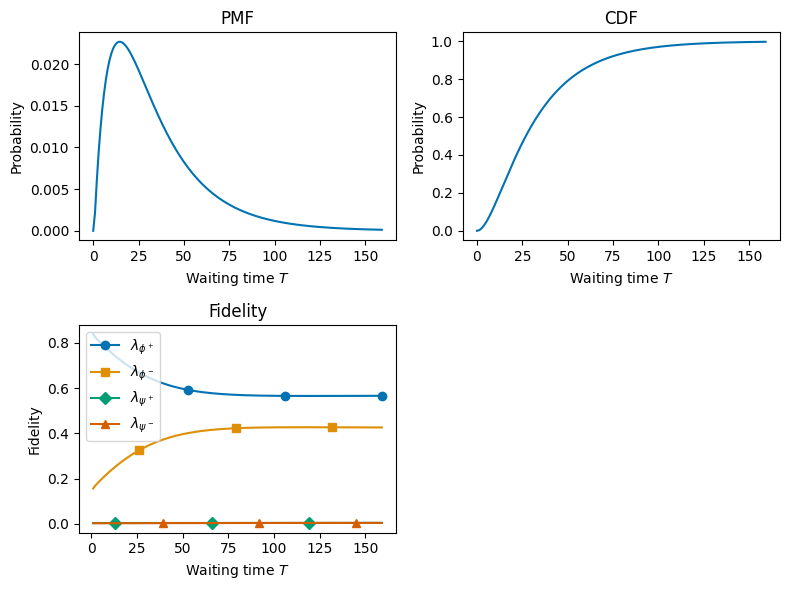

In [7]:
state_type : QuantumState = BellState
machinery = RepeaterChainEvaluation(state_type=state_type, twirling=False)

dist_pmf, dist_sf = machinery.nested_protocol(parameters)
fig, axs = plot_algorithm(
    pmf=dist_pmf,
    fid_func=dist_sf,
    legend_fid=["$\\lambda_{\\phi^+}$", "$\\lambda_{\\phi^-}$", "$\\lambda_{\\psi^+}$", "$\\lambda_{\\psi^-}$"]
)
plt.show()

## Asymmetric (non-nested) protocols
We can increase complexity by considering asymmetric protocols.

These are protocols that differ from the *doubling* nested structure of the previous examples.

They can be represented as binary trees of swapping and distillation operations where:
- nodes represent entangled links,
- nodes' labels represent the number of ro. of distillation on a link,
- edges of the tree represent how link are combined.

Since any swap takes either $0$ or $2$ links in input, the trees are **full binary trees**.

Here, we consider and test the following protocol.

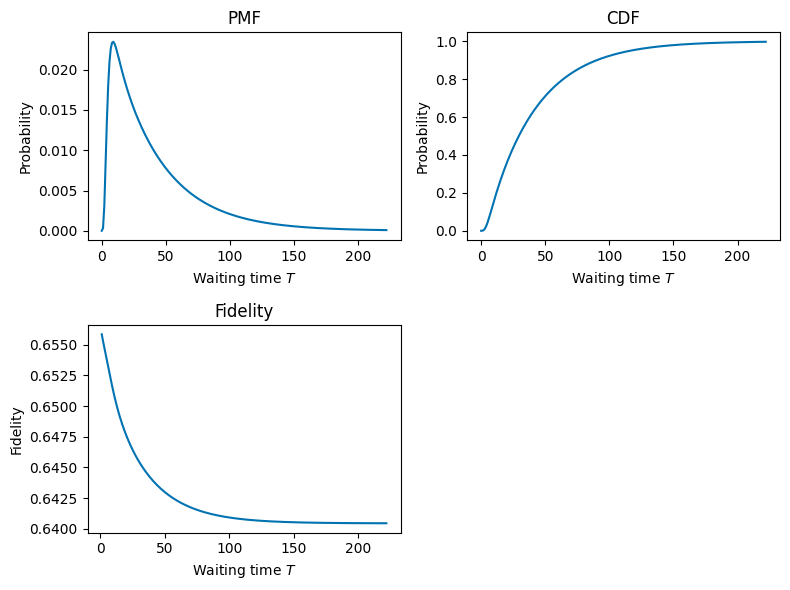

In [8]:
asymmetric_protocol = ("d0", "s0", "s1")
#         0
#        / \
#       0   0
#      / \  
#     1   0 
# The three leaves represent the three elementary links
# The leftmost link undergoes one round of distillation before being swapped with the middle link
# Finally, the resulting link is swapped with the rightmost link

state_type : QuantumState = WernerState
machinery = RepeaterChainEvaluation(state_type=state_type)
parameters = {
    "protocol": asymmetric_protocol,
    "p_gen": 0.2,
    "p_swap": 0.5,
    "w0": 0.8,  # fidelity 0.85
    "t_coh": 1000, # depolarizing noise
    "t_trunc": 1000,
}
asym_pmf, asym_fid_func = machinery.asymmetric_homogeneous_protocol(parameters, number_of_segments=3)
asym_fid_func = [werner_to_fid(w) for w in asym_fid_func]
fig, axs = plot_algorithm(
    pmf=asym_pmf,
    fid_func=asym_fid_func,
)
plt.show()

Again, the same protocol can be tested using the Bell-diagonal-state representation.

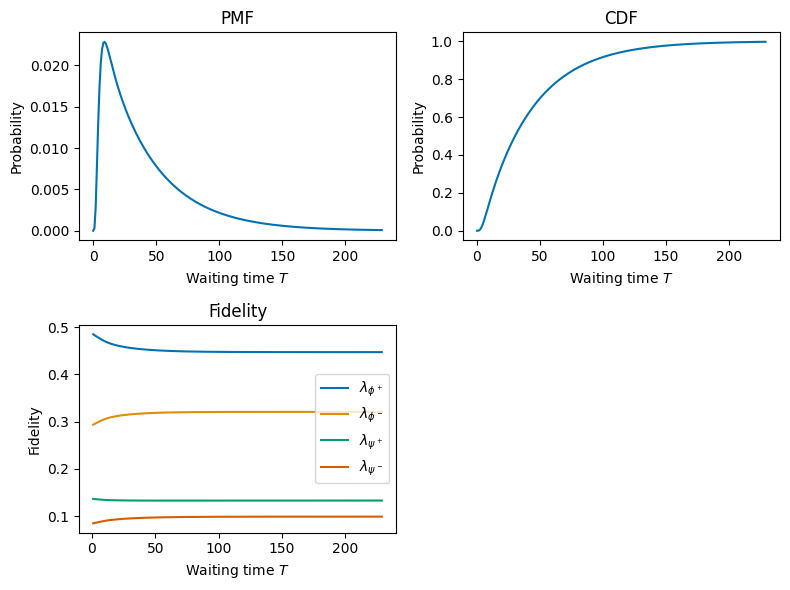

In [9]:
state_type : QuantumState = BellState
machinery = RepeaterChainEvaluation(state_type=state_type, twirling=False)
parameters = {
    "protocol": asymmetric_protocol,
    "p_gen": 0.2,
    "p_swap": 0.5,
    "lambdas": [0.75, 0.13, 0.1, 0.02],
    "depolarizing_rate": 0.001, # depolarizing noise
    "dephasing_rate": 0.01,
    "t_trunc": 1000,
}
asym_bell_pmf, asym_l_func = machinery.asymmetric_homogeneous_protocol(parameters, number_of_segments=3)
fig, axs = plot_algorithm(
    pmf=asym_bell_pmf,
    fid_func=asym_l_func,
    legend_fid=["$\\lambda_{\\phi^+}$", "$\\lambda_{\\phi^-}$", "$\\lambda_{\\psi^+}$", "$\\lambda_{\\psi^-}$"],
)
plt.show()

## Asymmetric Heterogeneous Protocols
We can also consider asymmetric protocols with heterogeneous hardware
That is,
- each link can have different a different probability of generation and initial quality,
- each node can have a different memory coherence time.

In [10]:
state_type : QuantumState = WernerState
machinery = RepeaterChainEvaluation(state_type=state_type)
parameters = {
    "p_gen": [0.1, 0.1, 0.05],
    "p_swap": 0.5,
    "w0": [0.9, 0.9, 0.9],  # fidelity for the 3 links
    "t_coh": [1000, 1000, 1000, 1000],  # coherence time for the 4 nodes
    "t_trunc": 1000,
}

# For example, consider the protocols
#         0
#        / \
#       0   0
#      / \  
#     0   0 
asymmetric_protocol_left = ("s0", "s1")
# and
#         0
#        / \
#       0   0
#          / \
#         0   0
asymmetric_protocol_right = ("s1", "s0")

parameters["protocol"] = asymmetric_protocol_left
asym_het_pmf_left, asym_het_fid_func_left = machinery.asymmetric_heterogeneous_protocol(
    parameters,
    number_of_segments=3,
)
print("Mean waiting time (left-swap-first):", get_mean_waiting_time(asym_het_pmf_left))
print("Average fidelity (left-swap-first):", get_mean(asym_het_pmf_left, [werner_to_fid(w) for w in asym_het_fid_func_left]))

parameters["protocol"] = asymmetric_protocol_right
asym_het_pmf_right, asym_het_fid_func_right = machinery.asymmetric_heterogeneous_protocol(
    parameters,
    number_of_segments=3,
)
print("Mean waiting time (right-swap-first):", get_mean_waiting_time(asym_het_pmf_right))
print("Average fidelity (right-swap-first):", get_mean(asym_het_pmf_right, [werner_to_fid(w) for w in asym_het_fid_func_right]))

Mean waiting time (left-swap-first): 73.268056761235
Average fidelity (left-swap-first): 0.7622937972077461
Mean waiting time (right-swap-first): 94.85891522198926
Average fidelity (right-swap-first): 0.7422893232999151


On average, the rightmost link takes longer to generate (because of its $p_\text{gen}$).

The protocol that swaps the rightmost link last performs better (less waiting time, higher fidelity).

This is because, while waiting for this link to be ready, the other two links are generated and then swapped.

Thus, the time links have to wait for their adjacent in memory is minimized.

-----------------------
We can also evaluate **asymmetric heterogenous protocols with Bell diagonal states**.

We set different generation success probabilities and lambdas for the three different links and different coherence times for the four nodes.

Mean waiting time (left-swap-first, Bell): 73.268056761235
Average fidelity (left-swap-first, Bell): 0.4800052151152141


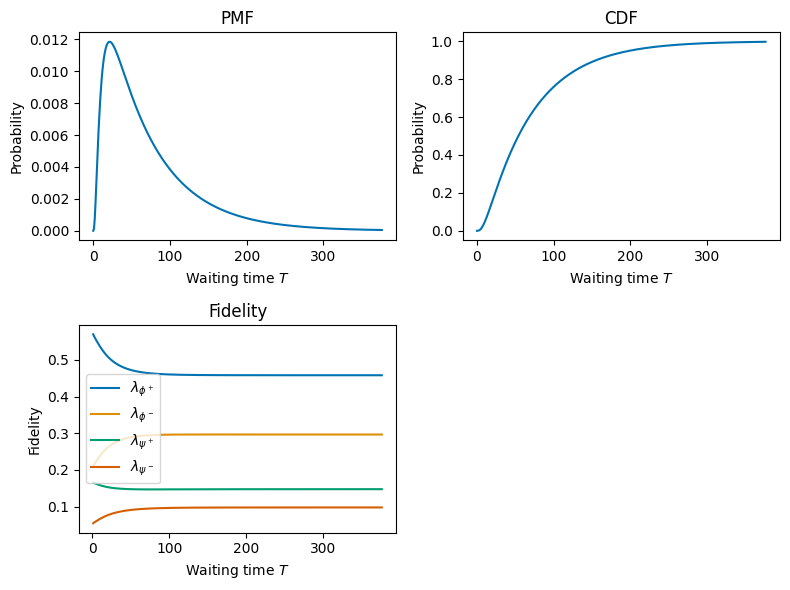

In [11]:
state_type : QuantumState = BellState
machinery = RepeaterChainEvaluation(state_type=state_type, twirling=False)
parameters = {
    "p_gen": [0.1, 0.1, 0.05],
    "p_swap": 0.5,
    "lambdas": [[0.75, 0.14, 0.1, 0.01], 
                [0.75, 0.14, 0.1, 0.01], 
                [0.95, 0.01, 0.03, 0.01]],
    "depolarizing_rate": [0.001, 0.001, 0.001, 0.001],
    "dephasing_rate": [0.01, 0.01, 0.01, 0.01],
    "t_trunc": 1000,
}
# For example, consider the protocols
#         0
#        / \
#       0   0
#      / \  
#     0   0 
asymmetric_protocol_left = ("s0", "s1")
parameters["protocol"] = asymmetric_protocol_left
asym_het_bell_pmf_left, asym_het_bell_l_func_left = machinery.asymmetric_heterogeneous_protocol(
    parameters,
    number_of_segments=3,
)
print("Mean waiting time (left-swap-first, Bell):", get_mean_waiting_time(asym_het_bell_pmf_left))
l_fid_func_left = [bell_to_fid(lambdas) for lambdas in asym_het_bell_l_func_left]
print("Average fidelity (left-swap-first, Bell):", get_mean(asym_het_bell_pmf_left, l_fid_func_left))

fig, axs = plot_algorithm(
    pmf=asym_het_bell_pmf_left,
    fid_func=asym_het_bell_l_func_left,
    legend_fid=["$\\lambda_{\\phi^+}$", "$\\lambda_{\\phi^-}$", "$\\lambda_{\\psi^+}$", "$\\lambda_{\\psi^-}$"],
)
plt.show()


## Testing the Efficiency of Bell-diagonal solver

In [12]:
# Test with different t_trunc values
t_trunc_values = [2**n * 1000 for n in range(0, 10)] 

werner_results = []
bell_results = []

print("Testing Werner state protocol with different t_trunc values:")
print("-" * 80)

for t_trunc in t_trunc_values:
    parameters_werner = {
        "p_gen": 0.00092,
        "p_swap": 0.85,
        "w0": 0.952,
        "t_coh": 1000,
        "t_trunc": t_trunc,
        "protocol": ("d1", "d2", "s1", "d2", "s2", "d0", "d3", "s0", "d3"),
    }
    simulator = RepeaterChainEvaluation(state_type=WernerState)
    
    start_time = time.time()
    dist_pmf, dist_sf = simulator.asymmetric_homogeneous_protocol(parameters_werner, number_of_segments=5)
    execution_time = time.time() - start_time
    
    werner_results.append({
        't_trunc': t_trunc,
        'time': execution_time,
        'pmf_shape': dist_pmf.shape,
    })
    
    print(f"t_trunc={t_trunc:6d} | Execution time: {execution_time:8.4f} seconds | PMF shape: {dist_pmf.shape}")

print("\n" + "=" * 80 + "\n")
print("Testing Bell state protocol with different t_trunc values:")
print("-" * 80)

for t_trunc in t_trunc_values:
    parameters_bell = {
        "p_gen": 0.00092,
        "p_swap": 0.85,
        "lambdas": [0.964, 0.012, 0.012, 0.012],
        "depolarizing_rate": 0.001,
        "dephasing_rate": 0.01,
        "t_trunc": t_trunc,
        "protocol": ("d1", "d2", "s1", "d2", "s2", "d0", "d3", "s0", "d3"),
    }
    simulator = RepeaterChainEvaluation(state_type=BellState)
    
    start_time = time.time()
    dist_pmf, dist_sf = simulator.asymmetric_homogeneous_protocol(parameters_bell, number_of_segments=5)
    execution_time = time.time() - start_time
    
    bell_results.append({
        't_trunc': t_trunc,
        'time': execution_time,
        'pmf_shape': dist_pmf.shape,
    })
    
    print(f"t_trunc={t_trunc:6d} | Execution time: {execution_time:8.4f} seconds | PMF shape: {dist_pmf.shape}")

print("\n" + "=" * 80 + "\n")
print("Summary Comparison:")
print("-" * 80)
print(f"{'t_trunc':<10} {'Werner (s)':<15} {'Bell (s)':<15} {'Ratio (Bell/Werner)':<20}")
print("-" * 80)
for i, t_trunc in enumerate(t_trunc_values):
    werner_time = werner_results[i]['time']
    bell_time = bell_results[i]['time']
    ratio = bell_time / werner_time if werner_time > 0 else 0
    print(f"{t_trunc:<10} {werner_time:<15.4f} {bell_time:<15.4f} {ratio:<20.2f}")


Testing Werner state protocol with different t_trunc values:
--------------------------------------------------------------------------------
t_trunc=  1000 | Execution time:   0.0128 seconds | PMF shape: (1000,)
t_trunc=  2000 | Execution time:   0.0147 seconds | PMF shape: (2000,)
t_trunc=  4000 | Execution time:   0.0197 seconds | PMF shape: (4000,)


t_trunc=  8000 | Execution time:   0.0306 seconds | PMF shape: (8000,)
t_trunc= 16000 | Execution time:   0.0534 seconds | PMF shape: (16000,)


t_trunc= 32000 | Execution time:   0.1029 seconds | PMF shape: (32000,)


t_trunc= 64000 | Execution time:   0.2124 seconds | PMF shape: (64000,)


t_trunc=128000 | Execution time:   0.3825 seconds | PMF shape: (128000,)


...

/Users/lorenzolacorte/Research/lilla/src/core/bell/protocol_units_efficient.py:298: RuntimeWarning: overflow encountered in exp
  link1_decay = np.exp((gamma1 + delta1) * time_axis)
/Users/lorenzolacorte/Research/lilla/src/core/bell/protocol_units_efficient.py:299: RuntimeWarning: overflow encountered in exp
  link2_decay = np.exp((gamma2 + delta2) * time_axis)
/Users/lorenzolacorte/Research/lilla/src/core/bell/protocol_units_efficient.py:306: RuntimeWarning: invalid value encountered in multiply
  pmf1[:, np.newaxis] * (a_diff / 2.0)[:, np.newaxis] * link2_decay[:, np.newaxis] * ones,
/Users/lorenzolacorte/Research/lilla/src/core/bell/protocol_units_efficient.py:308: RuntimeWarning: invalid value encountered in multiply
  pmf2[:, np.newaxis] * (b_diff / 2.0)[:, np.newaxis] * link1_decay[:, np.newaxis] * ones,
/Users/lorenzolacorte/Research/lilla/src/core/bell/protocol_units_efficient.py:201: RuntimeWarning: overflow encountered in exp
  link1_decay = np.exp((gamma1 + delta1) * time_ax

t_trunc=128000 | Execution time:   8.1310 seconds | PMF shape: (128000,)


/Users/lorenzolacorte/Research/lilla/src/core/bell/protocol_units_efficient.py:210: RuntimeWarning: invalid value encountered in multiply
  pmf1[:, np.newaxis] * lambdas_a[:, np.newaxis] * link2_decay[:, np.newaxis],
/Users/lorenzolacorte/Research/lilla/src/core/bell/protocol_units_efficient.py:212: RuntimeWarning: invalid value encountered in multiply
  pmf2[:, np.newaxis] * lambdas_b * link1_decay[:, np.newaxis],





t_trunc=256000 | Execution time:  16.5842 seconds | PMF shape: (256000,)


t_trunc=512000 | Execution time:  33.8835 seconds | PMF shape: (512000,)


Summary Comparison:
--------------------------------------------------------------------------------
t_trunc    Werner (s)      Bell (s)        Ratio (Bell/Werner) 
--------------------------------------------------------------------------------
1000       0.0128          0.0849          6.65                
2000       0.0147          0.1493          10.13               
4000       0.0197          0.2710          13.73               
8000       0.0306          0.5185          16.97               
16000      0.0534          1.0214          19.14               
32000      0.1029          2.0150          19.58               
64000      0.2124          4.0223          18.94               
128000     0.3825          8.1310          21.26               
256000     0.8568          16.5842         19.36               
512000     1.7825          33.8835         19.01               


## Bayesian Optimization

First, we show it on Werner states and homogeneous hardware.

In [13]:
parameters: SimParameters = {
    "p_gen": 0.00092,
    "p_swap": 0.85,
    "w0": 0.952,
    "t_coh": 1400000
}
simulator = RepeaterChainEvaluation(state_type=WernerState)

gaussian_optimization(
    simulator=simulator,
    parameters=parameters,
    nodes=5,
    max_dists=1,
    gp_shots=20,
    gp_initial_points=2,
    filename=None,
    cdf_threshold=0.99,
    random_state=42,
)

INFO:root:

Number of nodes: 5, max dists: 1, seed: 42
INFO:root:Gaussian process with 20 evaluations and 2 initial points


INFO:root:

Generating a protocol with gamma=0.18343478986616382, eta=0.559382000545539, tau=0.5968501579464871, kappa=6
INFO:root:Protocol generated: ('d2', 's1', 'd2', 'd3', 's2', 'd0', 'd3', 's0', 'd3')
INFO:root:
(1/20) Running: {'p_gen': 0.00092, 'p_swap': 0.85, 'w0': 0.952, 't_coh': 1400000, 'protocol': ('d2', 's1', 'd2', 'd3', 's2', 'd0', 'd3', 's0', 'd3'), 't_trunc': 1400000}
INFO:root:Protocol ('d2', 's1', 'd2', 'd3', 's2', 'd0', 'd3', 's0', 'd3'),	 r = 4.778570640187657e-05

INFO:root:

Generating a protocol with gamma=0.09997491581800291, eta=-0.08150221606826547, tau=0.3337086111390219, kappa=3
INFO:root:Protocol generated: ('d3', 's2', 'd3', 's1', 'd0', 's0')
INFO:root:
(2/20) Running: {'p_gen': 0.00092, 'p_swap': 0.85, 'w0': 0.952, 't_coh': 1400000, 'protocol': ('d3', 's2', 'd3', 's1', 'd0', 's0'), 't_trunc': 1400000}
INFO:root:Protocol ('d3', 's2',

KeyboardInterrupt: 

------------

Then, **Werner states** with heterogeneous hardware.

In [ ]:
# Then, we switch to heterogeneous hardware
parameters: SimParameters = {
    "p_gen": [0.025,0.0025,0.0025],
    "p_swap": 0.85,
    "w0": [0.95,0.95,0.90],
    "t_coh": [100000,100000,10000,100000]
}
simulator = RepeaterChainEvaluation(state_type=WernerState)

gaussian_optimization(
    simulator=simulator,
    parameters=parameters,
    nodes=4,
    max_dists=1,
    gp_shots=20,
    gp_initial_points=2,
    filename=None,
    cdf_threshold=0.99
)


INFO:root:

Number of nodes: 4, max dists: 1, seed: None
INFO:root:Gaussian process with 20 evaluations and 2 initial points


INFO:root:

Generating a protocol with gamma=0.40347700130725295, eta=-0.9203080122901866, tau=0.14434448335508424, kappa=4
INFO:root:Protocol generated: ('d1', 'd2', 's1', 'd0', 'd2', 's0')
INFO:root:
(1/20) Running: {'p_gen': [0.025, 0.0025, 0.0025], 'p_swap': 0.85, 'w0': [0.95, 0.95, 0.9], 't_coh': [100000, 100000, 10000, 100000], 'protocol': ('d1', 'd2', 's1', 'd0', 'd2', 's0'), 't_trunc': 145842}
INFO:root:Protocol ('d1', 'd2', 's1', 'd0', 'd2', 's0'),	 r = 3.149614130393665e-05

INFO:root:

Generating a protocol with gamma=0.3851093301636085, eta=0.5428771064553204, tau=0.07137594769526003, kappa=5
INFO:root:Protocol generated: ('d1', 'd2', 's1', 'd0', 'd2', 's0', 'd2')
INFO:root:
(2/20) Running: {'p_gen': [0.025, 0.0025, 0.0025], 'p_swap': 0.85, 'w0': [0.95, 0.95, 0.9], 't_coh': [100000, 100000, 10000, 100000], 'protocol': ('d1', 'd2', 's1', 'd0', 'd2', 

------------

Now, we use **Bell states** with homogeneous hardware.

In [ ]:
parameters: SimParameters = {
    "p_gen": 0.0092,
    "p_swap": 0.85,
    "lambdas": [0.964, 0.012, 0.012, 0.012],
    "depolarizing_rate": 1e-6,
    # "dephasing_rate": 1e-3,
}
simulator = RepeaterChainEvaluation(state_type=BellState)

# parameters: SimParameters = {
#     "p_gen": 0.00092,
#     "p_swap": 0.85,
#     "w0": 0.952,
#     "t_coh": 1400000
# }

gaussian_optimization(
    simulator=simulator,
    parameters=parameters,
    nodes=5,
    max_dists=1,
    gp_shots=20,
    gp_initial_points=2,
    filename=None,
    cdf_threshold=0.99,
    random_state=42,
)


INFO:root:

Number of nodes: 5, max dists: 1, seed: 42
INFO:root:Gaussian process with 20 evaluations and 2 initial points


INFO:root:

Generating a protocol with gamma=0.18343478986616382, eta=0.559382000545539, tau=0.5968501579464871, kappa=6
INFO:root:Protocol generated: ('d2', 's1', 'd2', 'd3', 's2', 'd0', 'd3', 's0', 'd3')
INFO:root:
(1/20) Running: {'p_gen': 0.0092, 'p_swap': 0.85, 'lambdas': [0.964, 0.012, 0.012, 0.012], 'depolarizing_rate': 1e-06, 'protocol': ('d2', 's1', 'd2', 'd3', 's2', 'd0', 'd3', 's0', 'd3'), 't_trunc': 1000000}
INFO:root:Protocol ('d2', 's1', 'd2', 'd3', 's2', 'd0', 'd3', 's0', 'd3'),	 r = 0.0005078765443956188

INFO:root:

Generating a protocol with gamma=0.09997491581800291, eta=-0.08150221606826547, tau=0.3337086111390219, kappa=3
INFO:root:Protocol generated: ('d2', 's2', 's1', 'd0', 's0', 'd3')
INFO:root:
(2/20) Running: {'p_gen': 0.0092, 'p_swap': 0.85, 'lambdas': [0.964, 0.012, 0.012, 0.012], 'depolarizing_rate': 1e-06, 'protocol': ('d2', 's2', 's

------------

And finally, **Bell states** with heterogeneous hardware.

In [ ]:
parameters = {
    "p_gen": [0.025, 0.025, 0.020],
    "p_swap": 0.85,
    "lambdas": [[0.95, 0.01, 0.03, 0.01],
                [0.96, 0.01, 0.02, 0.01],
                [0.97, 0.01, 0.01, 0.01]],
    "depolarizing_rate": [1e-4, 1e-5, 1e-5, 1e-5],
    "dephasing_rate": [1e-3, 1e-3, 1e-3, 1e-3],
}
simulator = RepeaterChainEvaluation(state_type=BellState)

gaussian_optimization(
    simulator=simulator,
    parameters=parameters,
    nodes=4,
    max_dists=1,
    gp_shots=20,
    gp_initial_points=2,
    filename=None,
    cdf_threshold=0.99,
    random_state=42,
)

INFO:root:

Number of nodes: 4, max dists: 1, seed: 42
INFO:root:Gaussian process with 20 evaluations and 2 initial points


INFO:root:

Generating a protocol with gamma=0.18343478986616382, eta=0.559382000545539, tau=0.5968501579464871, kappa=4
INFO:root:Protocol generated: ('d2', 's1', 'd0', 'd2', 's0', 'd2')
INFO:root:
(1/20) Running: {'p_gen': [0.025, 0.025, 0.02], 'p_swap': 0.85, 'lambdas': [[0.95, 0.01, 0.03, 0.01], [0.96, 0.01, 0.02, 0.01], [0.97, 0.01, 0.01, 0.01]], 'depolarizing_rate': [0.0001, 1e-05, 1e-05, 1e-05], 'dephasing_rate': [0.001, 0.001, 0.001, 0.001], 'protocol': ('d2', 's1', 'd0', 'd2', 's0', 'd2'), 't_trunc': 99999}
INFO:root:Protocol ('d2', 's1', 'd0', 'd2', 's0', 'd2'),	 r = 0.0

INFO:root:

Generating a protocol with gamma=0.09997491581800291, eta=-0.08150221606826547, tau=0.3337086111390219, kappa=2
INFO:root:Protocol generated: ('d1', 's1', 'd2', 's0')
INFO:root:
(2/20) Running: {'p_gen': [0.025, 0.025, 0.02], 'p_swap': 0.85, 'lambdas': [[0.95, 0.01, 0.03, 0